In [13]:
from zarrnii import ZarrNii, ZarrNiiAtlas
from lumivox.data.manifest import discover_subjects
import numpy as np
import matplotlib.pyplot as plt

# Discover subjects from batch3
subs = discover_subjects("/nfs/trident3/lightsheet/prado/mouse_app_lecanemab_batch3")
sub = subs[0]
print(f"Subject: {sub['subject_id']}")
print(f"Zarr: {sub['zarr_path']}")
print(f"Dseg: {sub['dseg_path']}")

# Load atlas
atlas = ZarrNiiAtlas.from_files(
      dseg_path=sub["dseg_path"],
      labels_path=sub["labels_path"],
  )

print(f"\nAtlas shape: {atlas.dseg.shape}")
print(f"Regions:\n{atlas.labels_df}")


Subject: sub-AS161F3
Zarr: /nfs/trident3/lightsheet/prado/mouse_app_lecanemab_batch3/bids/derivatives/resampled/sub-AS161F3/micr/sub-AS161F3_sample-brain_acq-imaris4x_res-4um_SPIM.ome.zarr
Dseg: /nfs/trident3/lightsheet/prado/mouse_app_lecanemab_batch3/derivatives/spimquant-v0.6.0rc2_84a605e_ozx/sub-AS161F3/micr/sub-AS161F3_sample-brain_acq-imaris4x_seg-roi22_from-ABAv3_level-5_desc-deform_dseg.nii.gz

Atlas shape: (1, 224, 392, 142)
Regions:
    index                     name abbreviation
0       1        L_Olfactory areas        L_OLF
1       2        R_Olfactory areas        R_OLF
2       3              L_Isocortex        L_Iso
3       4              R_Isocortex        R_ISO
4       5  L_Hippocampal formation        L_HYP
5       6  R_Hippocampal formation        R_HYP
6       7               L_Amygdala        L_AMY
7       8               R_Amygdala        R_AMY
8       9               L_Striatum        L_STR
9      10               R_Striatum        R_STR
10     11               L

In [14]:
regions = ["L_Isocortex", "R_Isocortex", "L_Hippocampal formation", "R_Hippocampal formation"]

centers = atlas.sample_region_patches(
      n_patches=1000,
      region_ids=regions,
      seed=42,
  )

centers_arr = np.array(centers)  # (1000, 3) in physical coords (x, y, z) mm
print(f"Sampled {len(centers)} centers")
print(f"Coordinate ranges:")
print(f"  x: [{centers_arr[:,0].min():.2f}, {centers_arr[:,0].max():.2f}] mm")
print(f"  y: [{centers_arr[:,1].min():.2f}, {centers_arr[:,1].max():.2f}] mm")
print(f"  z: [{centers_arr[:,2].min():.2f}, {centers_arr[:,2].max():.2f}] mm")

Sampled 1000 centers
Coordinate ranges:
  x: [0.36, 10.97] mm
  y: [-14.25, -5.15] mm
  z: [-5.37, -0.09] mm


In [15]:
# Load the dseg as a numpy array for plotting
dseg_data = atlas.dseg.darr.compute().squeeze()
dseg_affine = atlas.dseg.affine.matrix

print(f"Dseg shape: {dseg_data.shape}, dtype: {dseg_data.dtype}")
print(f"Dseg affine:\n{dseg_affine}")

# Build a binary mask of the target regions (cortex=3,4 hippocampus=5,6)
target_ids = {3, 4, 5, 6}
target_mask = np.isin(dseg_data, list(target_ids))
print(f"Target region voxels: {target_mask.sum()} / {target_mask.size} ({100*target_mask.mean():.1f}%)")

Dseg shape: (224, 392, 142), dtype: float64
Dseg affine:
[[ 0.052  0.     0.    -0.   ]
 [ 0.    -0.052  0.    -0.   ]
 [ 0.     0.    -0.044  0.   ]
 [ 0.     0.     0.     1.   ]]
Target region voxels: 1436245 / 12468736 (11.5%)


In [16]:
# Cell 4
# Convert physical centers (x,y,z) to dseg voxel coords using zarrnii's affine
inv_affine = atlas.dseg.affine.invert()

# centers_arr is (N, 3) in physical (x, y, z) mm
# AffineTransform @ expects a (3, N) array
voxel_coords = (inv_affine @ centers_arr.T).T  # (N, 3) as voxel (i, j, k)

print(f"Voxel coord ranges:")
print(f"  i: [{voxel_coords[:,0].min():.1f}, {voxel_coords[:,0].max():.1f}]")
print(f"  j: [{voxel_coords[:,1].min():.1f}, {voxel_coords[:,1].max():.1f}]")
print(f"  k: [{voxel_coords[:,2].min():.1f}, {voxel_coords[:,2].max():.1f}]")
print(f"Dseg shape (Z, Y, X): {dseg_data.shape}")

Voxel coord ranges:
  i: [7.0, 211.0]
  j: [99.0, 274.0]
  k: [2.0, 122.0]
Dseg shape (Z, Y, X): (224, 392, 142)


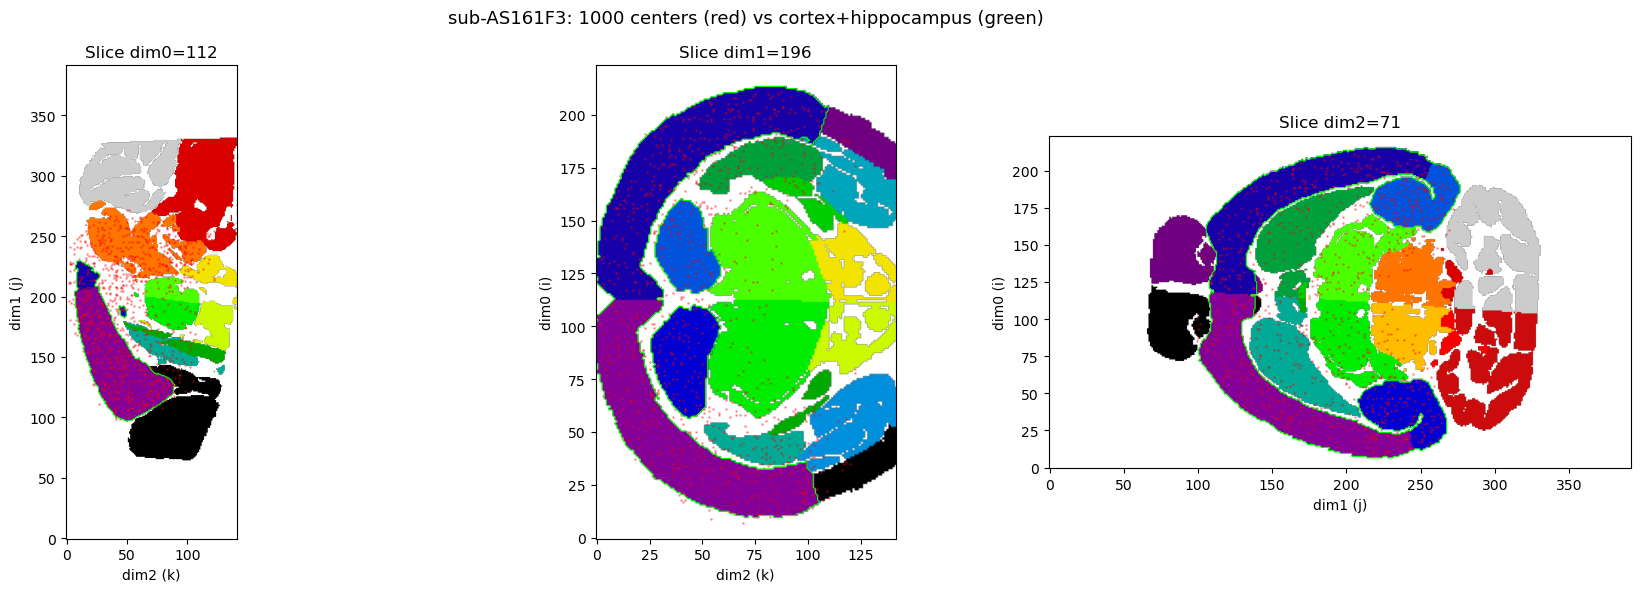

In [17]:
# Cell 5
# Make the atlas visible by masking background (0) and using discrete colors
import matplotlib.colors as mcolors

# Create a masked version so background is transparent
dseg_masked = np.ma.masked_where(dseg_data == 0, dseg_data)

vi = voxel_coords[:, 0]
vj = voxel_coords[:, 1]
vk = voxel_coords[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use discrete colormap for 22 regions + set vmin/vmax explicitly
vmin, vmax = 1, 22

# Slice through dim 0
ax = axes[0]
mid = dseg_data.shape[0] // 2
ax.imshow(dseg_masked[mid], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[mid], colors="lime", linewidths=0.8)
ax.scatter(vk, vj, s=1, c="red", alpha=0.3)
ax.set_title(f"Slice dim0={mid}")
ax.set_xlabel("dim2 (k)"); ax.set_ylabel("dim1 (j)")

# Slice through dim 1
ax = axes[1]
mid = dseg_data.shape[1] // 2
ax.imshow(dseg_masked[:, mid, :], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[:, mid, :], colors="lime", linewidths=0.8)
ax.scatter(vk, vi, s=1, c="red", alpha=0.3)
ax.set_title(f"Slice dim1={mid}")
ax.set_xlabel("dim2 (k)"); ax.set_ylabel("dim0 (i)")

# Slice through dim 2
ax = axes[2]
mid = dseg_data.shape[2] // 2
ax.imshow(dseg_masked[:, :, mid], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[:, :, mid], colors="lime", linewidths=0.8)
ax.scatter(vj, vi, s=1, c="red", alpha=0.3)
ax.set_title(f"Slice dim2={mid}")
ax.set_xlabel("dim1 (j)"); ax.set_ylabel("dim0 (i)")

fig.suptitle(f"{sub['subject_id']}: 1000 centers (red) vs cortex+hippocampus (green)", fontsize=13)
plt.tight_layout()
plt.show()

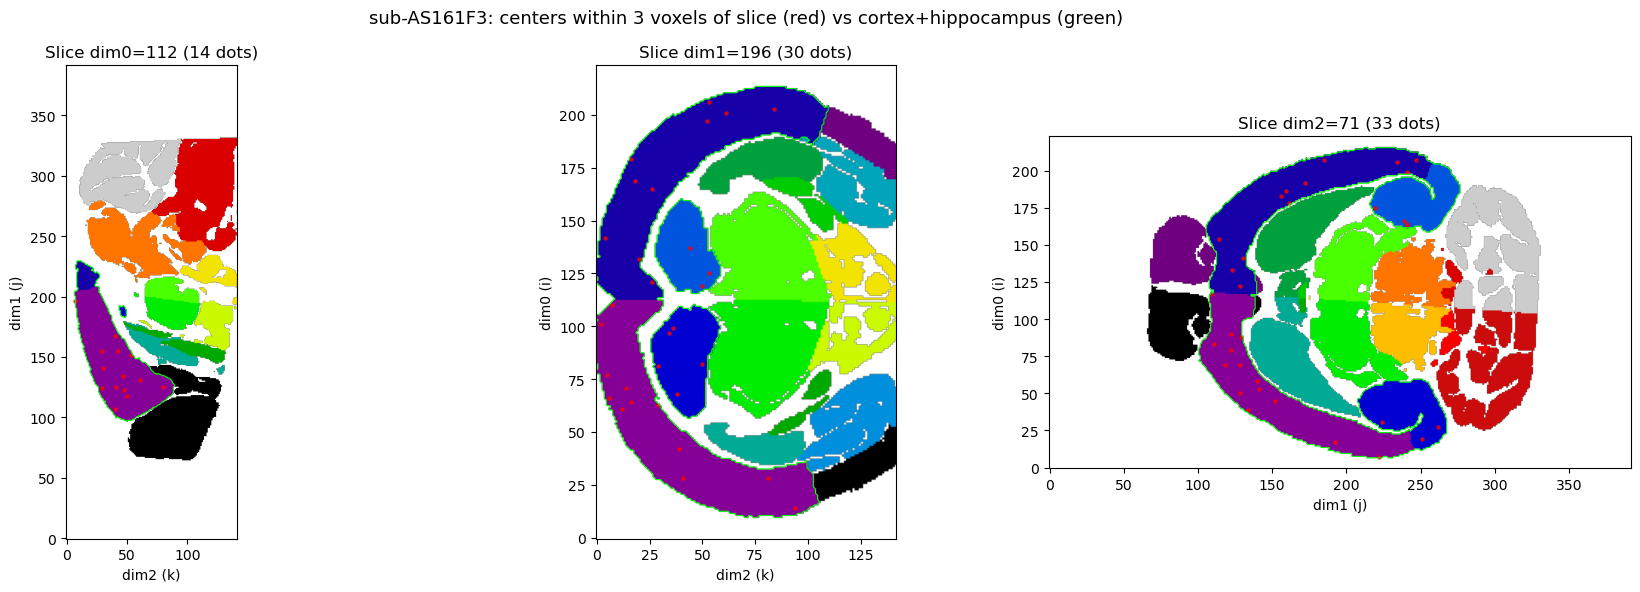

In [18]:
# Cell 5 rework
vi = voxel_coords[:, 0]
vj = voxel_coords[:, 1]
vk = voxel_coords[:, 2]

thickness = 3  # only show dots within +/- 3 voxels of the slice

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vmin, vmax = 1, 22

# Slice through dim 0
ax = axes[0]
mid = dseg_data.shape[0] // 2
near = np.abs(vi - mid) < thickness
ax.imshow(dseg_masked[mid], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[mid], colors="lime", linewidths=0.8)
ax.scatter(vk[near], vj[near], s=5, c="red", alpha=0.7)
ax.set_title(f"Slice dim0={mid} ({near.sum()} dots)")
ax.set_xlabel("dim2 (k)"); ax.set_ylabel("dim1 (j)")

# Slice through dim 1
ax = axes[1]
mid = dseg_data.shape[1] // 2
near = np.abs(vj - mid) < thickness
ax.imshow(dseg_masked[:, mid, :], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[:, mid, :], colors="lime", linewidths=0.8)
ax.scatter(vk[near], vi[near], s=5, c="red", alpha=0.7)
ax.set_title(f"Slice dim1={mid} ({near.sum()} dots)")
ax.set_xlabel("dim2 (k)"); ax.set_ylabel("dim0 (i)")

# Slice through dim 2
ax = axes[2]
mid = dseg_data.shape[2] // 2
near = np.abs(vk - mid) < thickness
ax.imshow(dseg_masked[:, :, mid], cmap="nipy_spectral", vmin=vmin, vmax=vmax, origin="lower")
ax.contour(target_mask[:, :, mid], colors="lime", linewidths=0.8)
ax.scatter(vj[near], vi[near], s=5, c="red", alpha=0.7)
ax.set_title(f"Slice dim2={mid} ({near.sum()} dots)")
ax.set_xlabel("dim1 (j)"); ax.set_ylabel("dim0 (i)")

fig.suptitle(f"{sub['subject_id']}: centers within {thickness} voxels of slice (red) vs cortex+hippocampus (green)", fontsize=13)
plt.tight_layout()
plt.show()

Abeta -> ch 0
Full-res shape: (1, 2272, 12544, 7168)
Full-res affine:
[[ 0.        0.        0.001625  0.      ]
 [ 0.       -0.001625  0.        0.      ]
 [-0.00275   0.        0.        0.      ]
 [ 0.        0.        0.        1.      ]]
Full-res axes_order: ZYX

Patch shape: (256, 256, 256)
Range: [79, 10450]
Std: 160.92


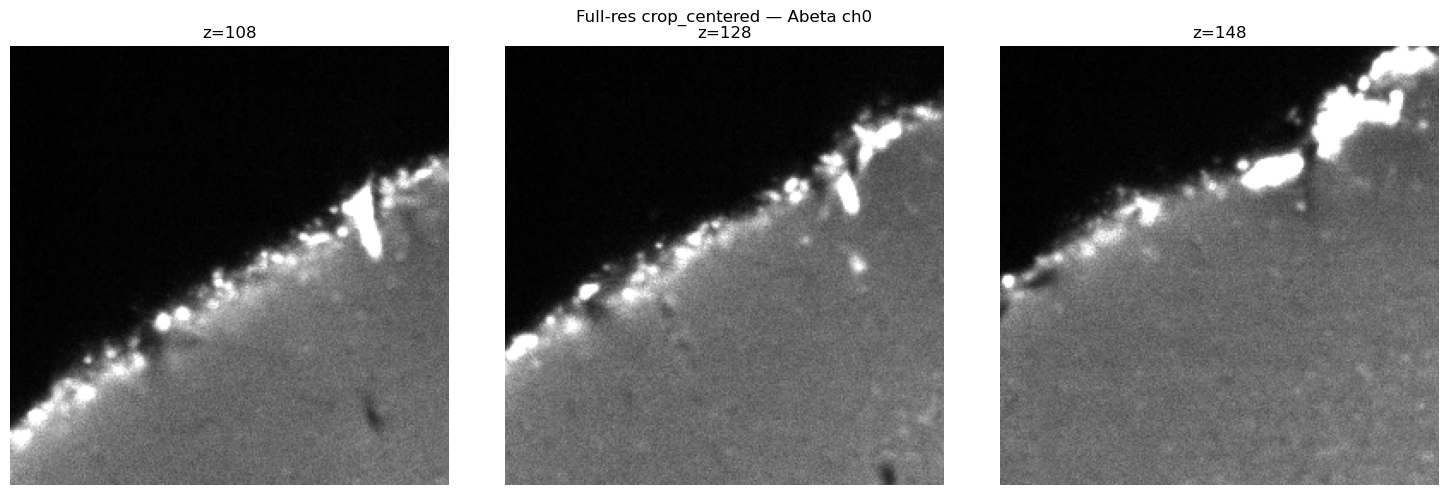

In [19]:
# Cell 6
from pathlib import Path

from lumivox.data.manifest import resolve_stain_channel                                                                                                                                                   
stain_ch = resolve_stain_channel(sub["zarr_path"], "Abeta", sub.get("fullres_zarr"))                                                                                                                      
print(f"Abeta -> ch {stain_ch}")

# Load full-res zarr with correct Abeta channel
fullres_path = str(list((Path(sub["dataset_root"]) / "bids" / sub["subject_id"] / "micr").glob("*_SPIM.ome.zarr"))[0])
znimg_full = ZarrNii.from_ome_zarr(fullres_path, channels=[stain_ch])
print(f"Full-res shape: {znimg_full.shape}")
print(f"Full-res affine:\n{znimg_full.affine.matrix}")
print(f"Full-res axes_order: {znimg_full.axes_order}")

# Crop at the same center
patch_full = znimg_full.crop_centered(centers[0], patch_size=(256, 256, 256))
patch_full_data = patch_full.darr.compute().squeeze().astype(np.float32)
print(f"\nPatch shape: {patch_full_data.shape}")
print(f"Range: [{patch_full_data.min():.0f}, {patch_full_data.max():.0f}]")
print(f"Std: {patch_full_data.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mid = patch_full_data.shape[0] // 2
for i, offset in enumerate([-20, 0, 20]):
  sl = mid + offset
  axes[i].imshow(patch_full_data[sl], cmap="gray",
                 vmin=np.percentile(patch_full_data, 1),
                 vmax=np.percentile(patch_full_data, 99))
  axes[i].set_title(f"z={sl}")
  axes[i].axis("off")
fig.suptitle(f"Full-res crop_centered — Abeta ch{stain_ch}")
plt.tight_layout()
plt.show()

In [20]:
# Cell 7
# Step 1: Where does crop_centered land in full-res voxel space?                                                                                                                                          
fullres_inv = znimg_full.affine.invert()                                                                                                                                                                  
center = centers[0]                                                                                                                                                                                       
print(f"Physical center (mm): {center}")                                                                                                                                                                  
print(f"Full-res affine:\n{znimg_full.affine.matrix}")    
print(f"Full-res axes_order: {znimg_full.axes_order}")                                                                                                                                                    
print(f"Full-res shape: {znimg_full.shape}")              
                                                                                                                                                                                                        
# Convert physical -> full-res voxel                                                                                                                                                                      
vox_fullres = fullres_inv @ np.array(center)
print(f"\nFull-res voxel coords: {vox_fullres}")                                                                                                                                                          
                                                                                                                                                                                                        
# Step 2: Use JSON sidecar to scale to resampled voxels                                                                                                                                                   
# "voxel_resampled = voxel_fullres * scale"                                                                                                                                                               
scale = {"z": 0.6875, "y": 0.40625, "x": 0.40625}                                                                                                                                                         
# But which axis is which? Let's check both orderings                                                                                                                                                     
print(f"\nJSON scale: {scale}")                                                                                                                                                                           
print(f"Resampled shape (CZYX): (3, 1561, 5096, 2912)")                                                                                                                                                   
                                                                                                                                                                                                        
# Try applying scale assuming vox_fullres is in (z, y, x) order                                                                                                                                           
vox_res_zyx = vox_fullres * np.array([scale["z"], scale["y"], scale["x"]])                                                                                                                                
print(f"Resampled voxel (assuming ZYX): {vox_res_zyx}")                                                                                                                                                   
                                                                                                                                                                                                        
# Try assuming vox_fullres is in (x, y, z) order                                                                                                                                                          
vox_res_xyz = vox_fullres * np.array([scale["x"], scale["y"], scale["z"]])                                                                                                                                
print(f"Resampled voxel (assuming XYZ): {vox_res_xyz}")                                                                                                                                                   
                                                                                                                                                                                                        
# Which one falls within the resampled shape (1561, 5096, 2912)?                                                                                                                                          
print(f"\nResampled spatial shape: (1561, 5096, 2912) = (Z, Y, X)")                                                                                                                                       
print(f"ZYX option in range? Z:{0<=vox_res_zyx[0]<1561} Y:{0<=vox_res_zyx[1]<5096} X:{0<=vox_res_zyx[2]<2912}")                                                                                           
print(f"XYZ option in range? X:{0<=vox_res_xyz[0]<2912} Y:{0<=vox_res_xyz[1]<5096} Z:{0<=vox_res_xyz[2]<1561}")

Physical center (mm): (4.264000087976456, -5.460000112652779, -1.7599999904632568)
Full-res affine:
[[ 0.        0.        0.001625  0.      ]
 [ 0.       -0.001625  0.        0.      ]
 [-0.00275   0.        0.        0.      ]
 [ 0.        0.        0.        1.      ]]
Full-res axes_order: ZYX
Full-res shape: (1, 2272, 12544, 7168)

Full-res voxel coords: [ 639.99999653 3360.00006932 2624.00005414]

JSON scale: {'z': 0.6875, 'y': 0.40625, 'x': 0.40625}
Resampled shape (CZYX): (3, 1561, 5096, 2912)
Resampled voxel (assuming ZYX): [ 439.99999762 1365.00002816 1066.00002199]
Resampled voxel (assuming XYZ): [ 259.99999859 1365.00002816 1804.00003722]

Resampled spatial shape: (1561, 5096, 2912) = (Z, Y, X)
ZYX option in range? Z:True Y:True X:True
XYZ option in range? X:True Y:True Z:False


Resampled patch shape: (256, 256, 256)
Center voxel (z,y,x): (440, 1365, 1066)
Range: [93, 65535], std: 319.3


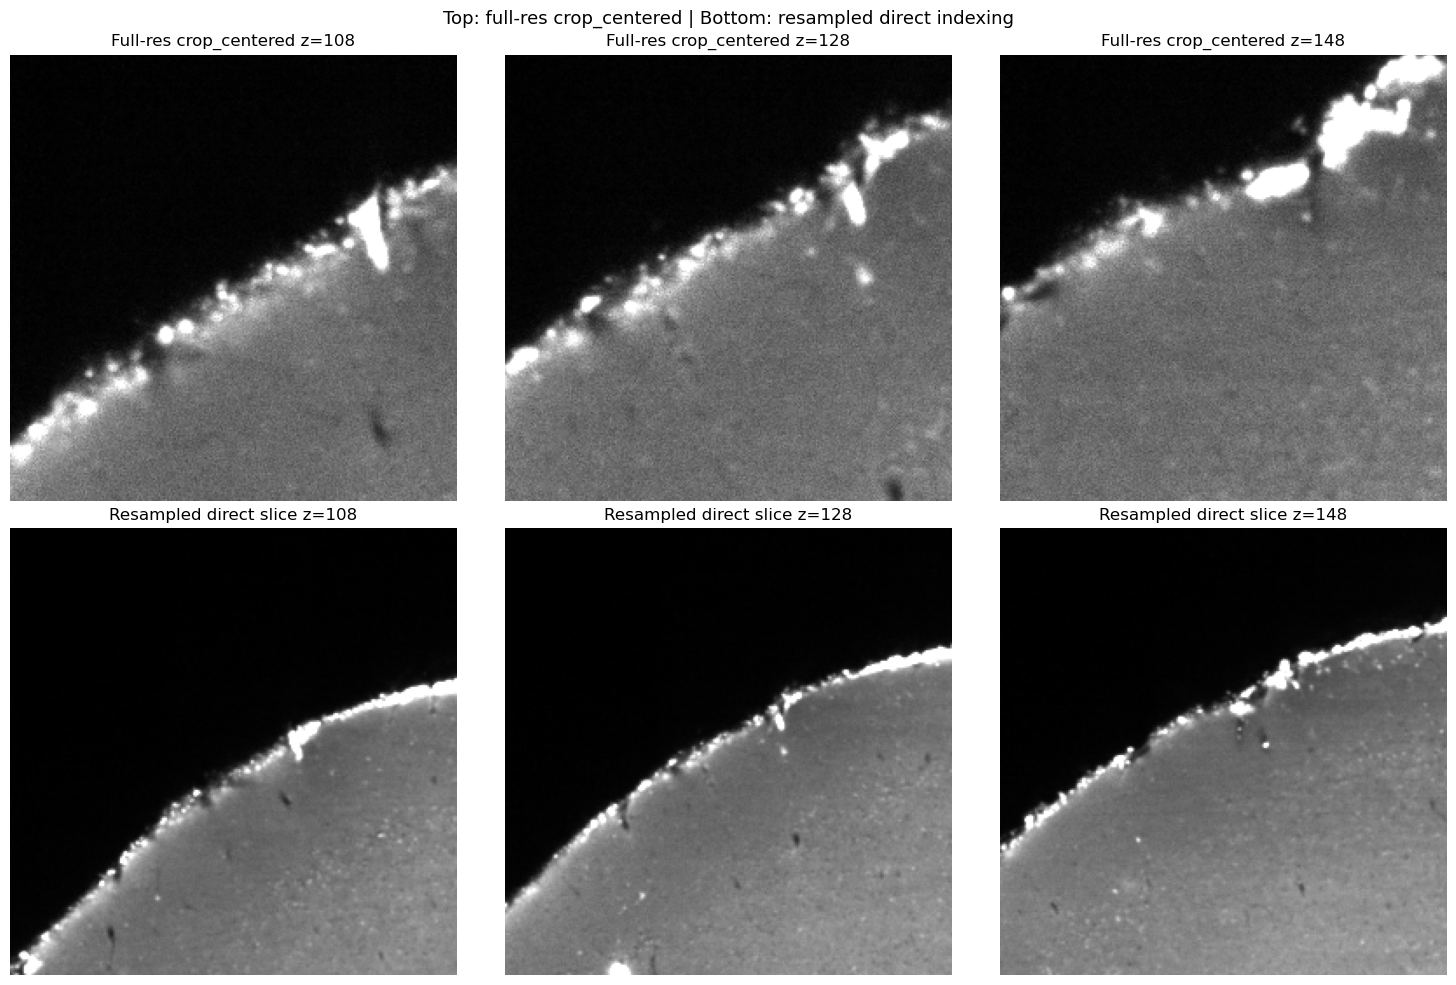

In [21]:
# Cell 8
# Read patch from resampled zarr using our computed voxel coords                                                                                                                                          
import dask.array as da                                                                                                                                                                                   

res_zarr = ZarrNii.from_ome_zarr(sub["zarr_path"], channels=[stain_ch])                                                                                                                                   
res_data = res_zarr.darr  # (1, Z, Y, X) dask array       
                                                                                                                                                                                                        
cz, cy, cx = int(round(vox_res_zyx[0])), int(round(vox_res_zyx[1])), int(round(vox_res_zyx[2]))                                                                                                           
half = 128  # half of 256                                                                                                                                                                                 
                                                                                                                                                                                                        
# Clip to array bounds                                                                                                                                                                                    
z0, z1 = max(0, cz - half), min(res_data.shape[1], cz + half)                                                                                                                                             
y0, y1 = max(0, cy - half), min(res_data.shape[2], cy + half)                                                                                                                                             
x0, x1 = max(0, cx - half), min(res_data.shape[3], cx + half)                                                                                                                                             
                                                                                                                                                                                                        
patch_res = res_data[0, z0:z1, y0:y1, x0:x1].compute().astype(np.float32)                                                                                                                                 
print(f"Resampled patch shape: {patch_res.shape}")                                                                                                                                                        
print(f"Center voxel (z,y,x): ({cz}, {cy}, {cx})")                                                                                                                                                        
print(f"Range: [{patch_res.min():.0f}, {patch_res.max():.0f}], std: {patch_res.std():.1f}")                                                                                                               
                                                                                                                                                                                                        
# Compare side by side with full-res crop_centered result                                                                                                                                                 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))                                                                                                                                                          
mid_res = patch_res.shape[0] // 2                                                                                                                                                                         
mid_full = patch_full_data.shape[0] // 2                                                                                                                                                                  
                                                                                                                                                                                                        
for i, offset in enumerate([-20, 0, 20]):                                                                                                                                                                 
  axes[0, i].imshow(patch_full_data[mid_full + offset], cmap="gray",                                                                                                                                    
                    vmin=np.percentile(patch_full_data, 1), vmax=np.percentile(patch_full_data, 99))                                                                                                    
  axes[0, i].set_title(f"Full-res crop_centered z={mid_full+offset}")                                                                                                                                   
  axes[0, i].axis("off")                                                                                                                                                                                
                                                                                                                                                                                                        
  axes[1, i].imshow(patch_res[mid_res + offset], cmap="gray",                                                                                                                                           
                    vmin=np.percentile(patch_res, 1), vmax=np.percentile(patch_res, 99))                                                                                                                
  axes[1, i].set_title(f"Resampled direct slice z={mid_res+offset}")                                                                                                                                    
  axes[1, i].axis("off")
                                                                                                                                                                                                        
fig.suptitle("Top: full-res crop_centered | Bottom: resampled direct indexing", fontsize=13)                                                                                                              
plt.tight_layout()
plt.show()

Loaded ch 0, shape: (1, 1561, 5096, 2912)
Patch std distribution (n=50):
  min=0.00, median=0.00, max=1370.12
  Patches with std > 5: 23 / 50
  Patches with std < 1: 26 / 50


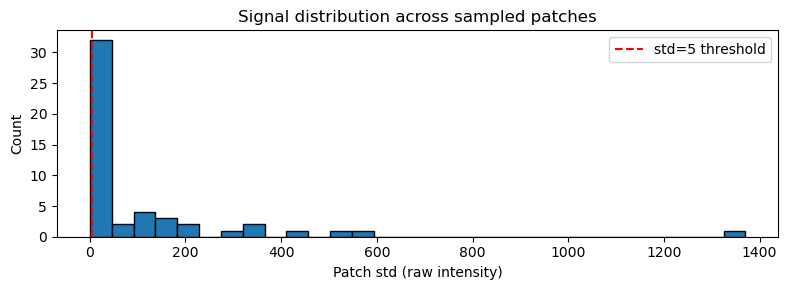

In [23]:
stain_ch = resolve_stain_channel(sub["zarr_path"], "Abeta", sub.get("fullres_zarr"))
znimg = ZarrNii.from_ome_zarr(sub["zarr_path"], channels=[stain_ch])
print(f"Loaded ch {stain_ch}, shape: {znimg.shape}")


n_sample = 50
rng = np.random.default_rng(99)
sample_idx = rng.choice(len(centers), size=n_sample, replace=False)

stds = []
for i in sample_idx:
  p = znimg.crop_centered(centers[i], patch_size=(256, 256, 256))
  d = p.darr.compute().squeeze().astype(np.float32)
  stds.append(d.std())

stds = np.array(stds)
print(f"Patch std distribution (n={n_sample}):")
print(f"  min={stds.min():.2f}, median={np.median(stds):.2f}, max={stds.max():.2f}")
print(f"  Patches with std > 5: {(stds > 5).sum()} / {n_sample}")
print(f"  Patches with std < 1: {(stds < 1).sum()} / {n_sample}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(stds, bins=30, edgecolor="black")
ax.set_xlabel("Patch std (raw intensity)")
ax.set_ylabel("Count")
ax.set_title("Signal distribution across sampled patches")
ax.axvline(5, color="red", ls="--", label="std=5 threshold")
ax.legend()
plt.tight_layout()
plt.show()

Patch std distribution (n=50):
  min=44.29, median=300.80, max=1194.82
  Patches with std > 5: 50 / 50
  Patches with std < 1: 0 / 50


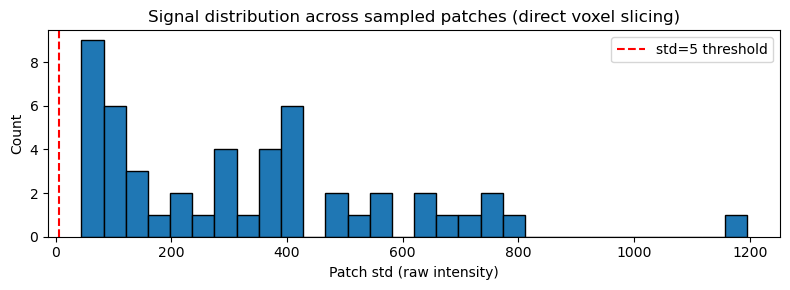

In [25]:
# Checking if patches are correct
from lumivox.data.manifest import resolve_stain_channel                                                                                                                                                   
import json                                                                                                                                                                                               
                                                                                                                                                                                                        
stain_ch = resolve_stain_channel(sub["zarr_path"], "Abeta", sub.get("fullres_zarr"))                                                                                                                      
znimg = ZarrNii.from_ome_zarr(sub["zarr_path"], channels=[stain_ch])                                                                                                                                      
                                                                                                                                                                                                        
# Load full-res affine + JSON sidecar for coordinate conversion                                                                                                                                           
fullres_path = sub.get("fullres_zarr")                                                                                                                                                                    
znimg_full = ZarrNii.from_ome_zarr(fullres_path, channels=[stain_ch])                                                                                                                                     
fullres_inv = znimg_full.affine.invert()                                                                                                                                                                  
                                                                                                                                                                                                        
sidecar_path = sub["zarr_path"] + ".json"                                                                                                                                                                 
with open(sidecar_path) as f:                                                                                                                                                                             
  sc = json.load(f)["fullres_to_resampled"]["scale"]                                                                                                                                                    
res_scale = np.array([sc["z"], sc["y"], sc["x"]])                                                                                                                                                         
                                                                                                                                                                                                        
# Sample 50 patches using direct voxel slicing                                                                                                                                                            
n_sample = 50                                                                                                                                                                                             
half = 128                                                                                                                                                                                                
rng = np.random.default_rng(99)                                                                                                                                                                           
sample_idx = rng.choice(len(centers), size=n_sample, replace=False)                                                                                                                                       
darr = znimg.darr                                                                                                                                                                                         
                                                                                                                                                                                                        
stds = []                                                                                                                                                                                                 
for i in sample_idx:                                                                                                                                                                                      
  vox_fullres = fullres_inv @ np.array(centers[i])                                                                                                                                                      
  vox_res = vox_fullres * res_scale                                                                                                                                                                     
  cz, cy, cx = int(round(vox_res[0])), int(round(vox_res[1])), int(round(vox_res[2]))                                                                                                                   
  z0, z1 = max(0, cz - half), min(darr.shape[1], cz + half)                                                                                                                                             
  y0, y1 = max(0, cy - half), min(darr.shape[2], cy + half)                                                                                                                                             
  x0, x1 = max(0, cx - half), min(darr.shape[3], cx + half)                                                                                                                                             
  patch = darr[0, z0:z1, y0:y1, x0:x1].compute().astype(np.float32)                                                                                                                                     
  stds.append(patch.std())                                                                                                                                                                              
                                                                                                                                                                                                        
stds = np.array(stds)                                                                                                                                                                                     
print(f"Patch std distribution (n={n_sample}):")                                                                                                                                                          
print(f"  min={stds.min():.2f}, median={np.median(stds):.2f}, max={stds.max():.2f}")                                                                                                                      
print(f"  Patches with std > 5: {(stds > 5).sum()} / {n_sample}")                                                                                                                                         
print(f"  Patches with std < 1: {(stds < 1).sum()} / {n_sample}")                                                                                                                                         
                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(8, 3))                                                                                                                                                                    
ax.hist(stds, bins=30, edgecolor="black")                                                                                                                                                                 
ax.set_xlabel("Patch std (raw intensity)")                                                                                                                                                                
ax.set_ylabel("Count")                                                                                                                                                                                    
ax.set_title("Signal distribution across sampled patches (direct voxel slicing)")                                                                                                                         
ax.axvline(5, color="red", ls="--", label="std=5 threshold")                                                                                                                                              
ax.legend()                                                                                                                                                                                               
plt.tight_layout()                                                                                                                                                                                        
plt.show()

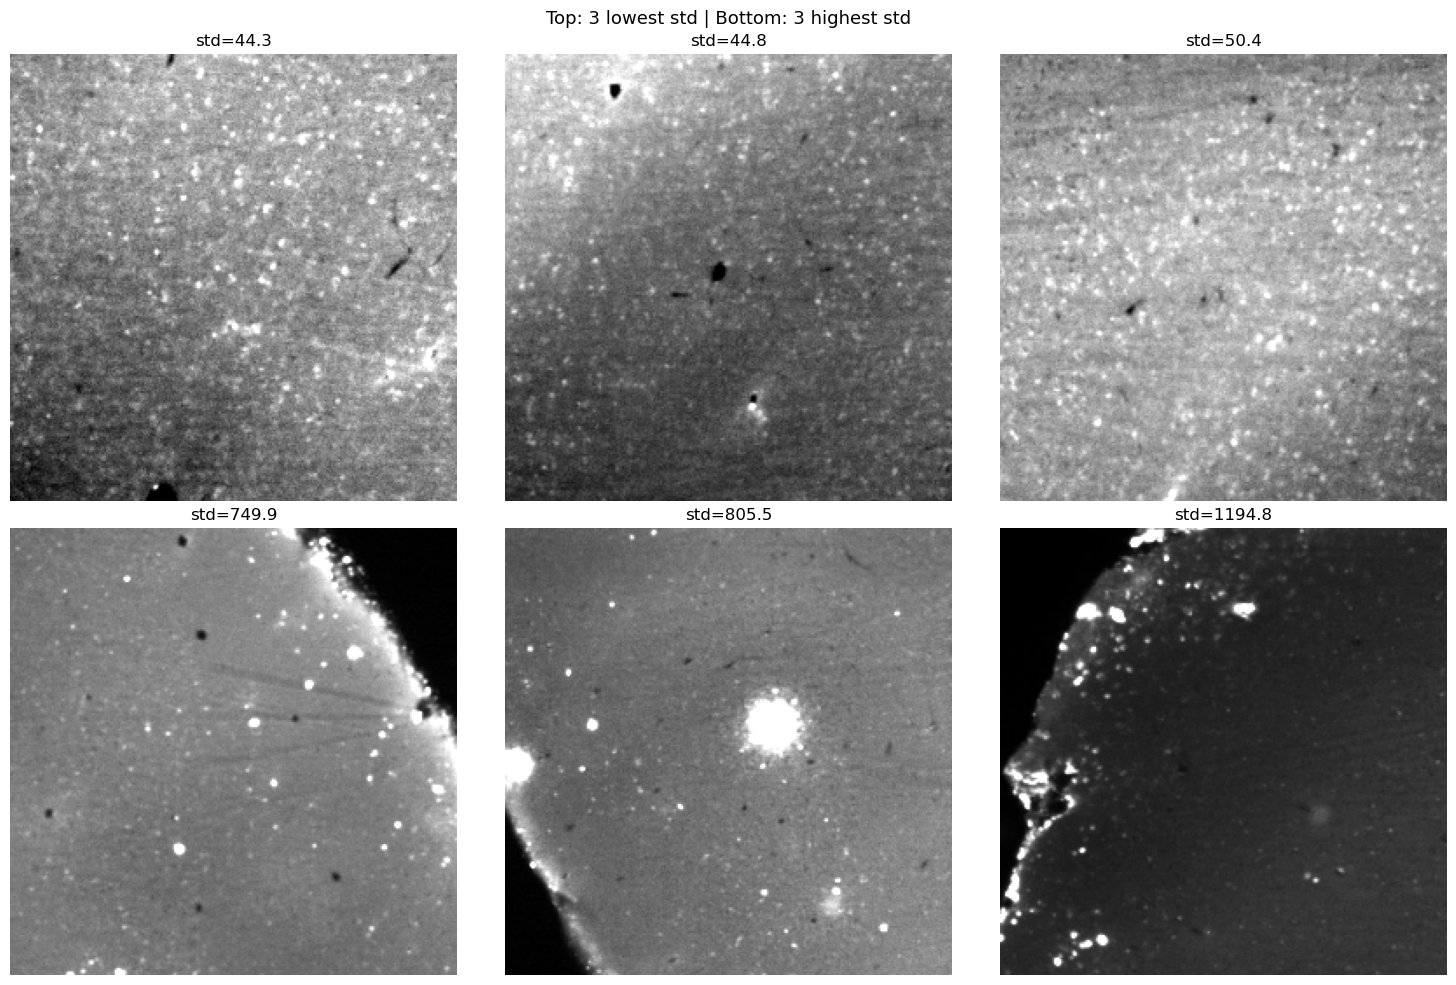

In [26]:
# Show 6 random patches — 3 high-std, 3 low-std                                                                                                                                                           
sorted_idx = sample_idx[np.argsort(stds)]                                                                                                                                                                 
picks = list(sorted_idx[:3]) + list(sorted_idx[-3:])                                                                                                                                                      
pick_stds = sorted(stds)[:3] + sorted(stds)[-3:]                                                                                                                                                          
                                                                                                                                                                                                        
fig, axes = plt.subplots(2, 3, figsize=(15, 10))                                                                                                                                                          
for ax, pidx, pstd in zip(axes.flat, picks, pick_stds):                                                                                                                                                   
  vox_fullres = fullres_inv @ np.array(centers[pidx])                                                                                                                                                   
  vox_res = vox_fullres * res_scale                                                                                                                                                                     
  cz, cy, cx = int(round(vox_res[0])), int(round(vox_res[1])), int(round(vox_res[2]))                                                                                                                   
  z0, z1 = max(0, cz - half), min(darr.shape[1], cz + half)                                                                                                                                             
  y0, y1 = max(0, cy - half), min(darr.shape[2], cy + half)                                                                                                                                             
  x0, x1 = max(0, cx - half), min(darr.shape[3], cx + half)                                                                                                                                             
  patch = darr[0, z0:z1, y0:y1, x0:x1].compute().astype(np.float32)                                                                                                                                     
  mid = patch.shape[0] // 2                                                                                                                                                                             
  ax.imshow(patch[mid], cmap="gray", vmin=np.percentile(patch, 1), vmax=np.percentile(patch, 99))                                                                                                       
  ax.set_title(f"std={pstd:.1f}")                                                                                                                                                                       
  ax.axis("off")                                                                                                                                                                                        
                                                                                                                                                                                                        
fig.suptitle("Top: 3 lowest std | Bottom: 3 highest std", fontsize=13)                                                                                                                                    
plt.tight_layout()                                                                                                                                                                                        
plt.show()   

Physical center: [2.13, -8.79, -1.54] mm
Dseg voxel: [np.float64(41.0), np.float64(169.0), np.float64(35.0)]
Resampled voxel (z,y,x): (385, 2197, 533)
Dseg label at center: 3 = ['L_Isocortex']


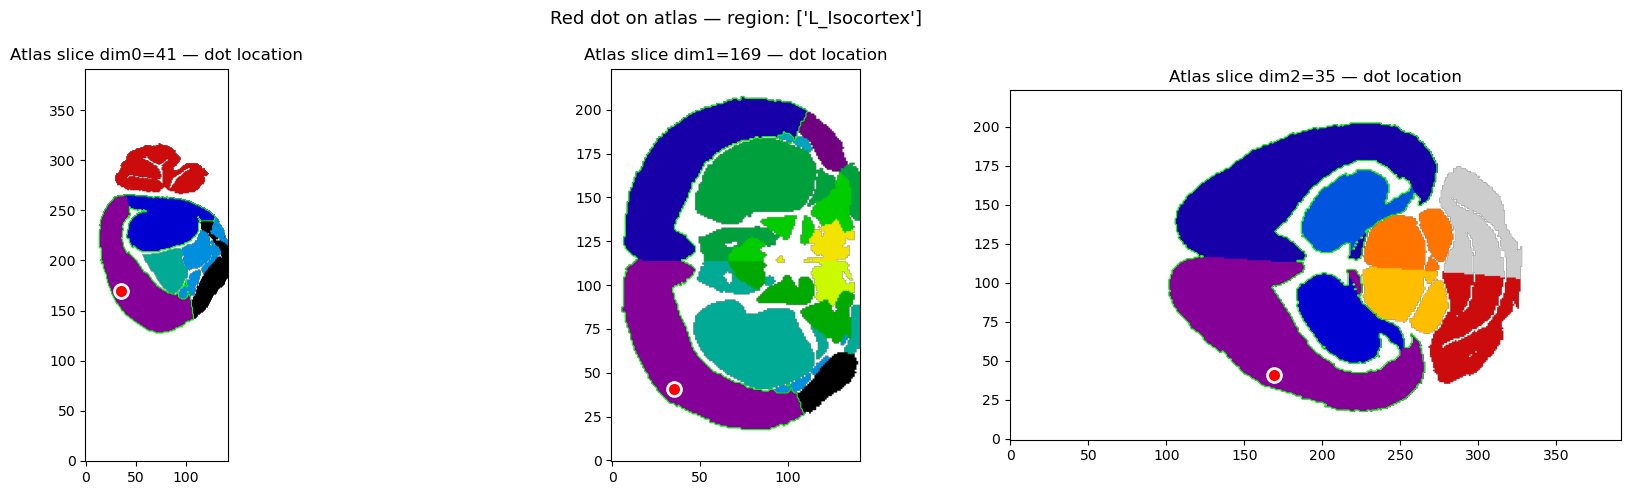

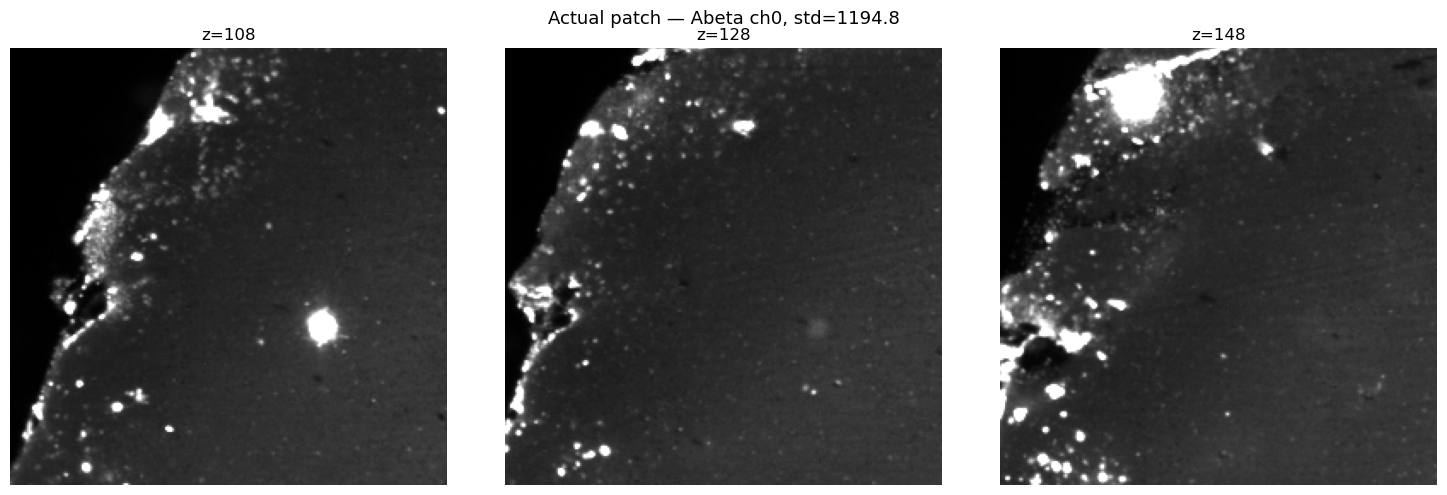

In [27]:
# Pick a patch with high std (has visible signal)
test_idx = sample_idx[np.argmax(stds)]
center = centers[test_idx]

# Convert to both dseg voxel and resampled voxel coords
inv_affine = atlas.dseg.affine.invert()
vox_dseg = inv_affine @ np.array(center)

vox_fullres = fullres_inv @ np.array(center)
vox_res = vox_fullres * res_scale
cz, cy, cx = int(round(vox_res[0])), int(round(vox_res[1])), int(round(vox_res[2]))

print(f"Physical center: {[round(c,2) for c in center]} mm")
print(f"Dseg voxel: {[round(v,1) for v in vox_dseg]}")
print(f"Resampled voxel (z,y,x): ({cz}, {cy}, {cx})")

# What region label is at this dseg voxel?
di, dj, dk = int(round(vox_dseg[0])), int(round(vox_dseg[1])), int(round(vox_dseg[2]))
label_val = dseg_data[di, dj, dk]
label_name = atlas.labels_df[atlas.labels_df["index"] == int(label_val)]["name"].values
print(f"Dseg label at center: {int(label_val)} = {label_name}")

# Show on atlas — slice through the dseg at this dot's location
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dseg dim0 slice at this dot's i-coord
ax = axes[0]
ax.imshow(dseg_masked[di], cmap="nipy_spectral", vmin=1, vmax=22, origin="lower")
ax.contour(target_mask[di], colors="lime", linewidths=0.8)
ax.plot(dk, dj, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
ax.set_title(f"Atlas slice dim0={di} — dot location")

# Dseg dim1 slice
ax = axes[1]
ax.imshow(dseg_masked[:, dj, :], cmap="nipy_spectral", vmin=1, vmax=22, origin="lower")
ax.contour(target_mask[:, dj, :], colors="lime", linewidths=0.8)
ax.plot(dk, di, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
ax.set_title(f"Atlas slice dim1={dj} — dot location")

# Dseg dim2 slice
ax = axes[2]
ax.imshow(dseg_masked[:, :, dk], cmap="nipy_spectral", vmin=1, vmax=22, origin="lower")
ax.contour(target_mask[:, :, dk], colors="lime", linewidths=0.8)
ax.plot(dj, di, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
ax.set_title(f"Atlas slice dim2={dk} — dot location")

plt.suptitle(f"Red dot on atlas — region: {label_name}", fontsize=13)
plt.tight_layout()
plt.show()

# Now show the actual patch extracted at that location
z0, z1 = max(0, cz - half), min(darr.shape[1], cz + half)
y0, y1 = max(0, cy - half), min(darr.shape[2], cy + half)
x0, x1 = max(0, cx - half), min(darr.shape[3], cx + half)
patch = darr[0, z0:z1, y0:y1, x0:x1].compute().astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mid = patch.shape[0] // 2
for i, offset in enumerate([-20, 0, 20]):
  sl = mid + offset
  axes[i].imshow(patch[sl], cmap="gray", vmin=np.percentile(patch, 1), vmax=np.percentile(patch, 99))
  axes[i].set_title(f"z={sl}")
  axes[i].axis("off")
fig.suptitle(f"Actual patch — Abeta ch{stain_ch}, std={stds[np.argmax(stds)]:.1f}", fontsize=13)
plt.tight_layout()
plt.show()